# NBA Player Performance Prediction

This project applies machine learning techniques to predict NBA player performance using game-level statistics from the 2024–2025 NBA season. The objective is to explore how historical player performance can be used to forecast future outcomes in a realistic predictive setting.

Two prediction tasks are investigated:

• Regression: Predict a player's Game Score (GmSc), an advanced metric that summarizes overall player performance in a single value using box score statistics.

• Classification: Predict whether a player will score 20+ points or 25+ points in a game.

To ensure realistic predictions and prevent data leakage, the models rely on rolling statistics calculated from prior games only. This approach simulates the type of information that would have been available before a game was played.

The workflow in this notebook includes:

• Data loading and preprocessing  
• Feature engineering using rolling player statistics  
• Exploratory data analysis of player performance trends  
• Model training using regression and classification algorithms  
• Evaluation of predictive performance using standard machine learning metrics

The goal of this project is not only to build predictive models, but also to demonstrate a complete sports analytics workflow that mirrors real-world machine learning pipelines used in data science and basketball analytics.

## Table of Contents

1. [Project Overview](#project-overview)
2. [Import Libraries](#import-libraries)
3. [Load Dataset](#load-dataset)
4. [Data Inspection](#data-inspection)
5. [Data Cleaning](#data-cleaning)
6. [Feature Engineering](#feature-engineering)
7. [Exploratory Data Analysis](#exploratory-data-analysis)
8. [Regression Model – Predicting Game Score](#regression-model--predicting-game-score)
9. [Classification Model – Predicting 20+ or 25+ Point Games](#classification-model--predicting-20-or-25-point-games)
10. [Model Evaluation](#model-evaluation)
11. [Results and Discussion](#results-and-discussion)
12. [Conclusion](#conclusion)

## Project Workflow

This notebook follows a standard machine learning workflow used in sports analytics projects.

Dataset → Data Cleaning → Feature Engineering → Exploratory Data Analysis → Model Training → Model Evaluation → Results

Steps in the pipeline:

1. Load game-level NBA player statistics from the 2024–2025 season dataset.
2. Inspect and clean the data to ensure consistent formatting and remove missing values.
3. Create rolling statistics using prior games to represent recent player performance.
4. Explore relationships between statistics through visualizations and summary metrics.
5. Train machine learning models to predict player performance.
6. Evaluate model accuracy using appropriate regression and classification metrics.
7. Analyze the results and discuss insights from the models.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

pd.set_option("display.max_columns", None)

## Load Dataset

The dataset contains player-level game statistics from the 2024–2025 NBA season.
Each row represents a single player's performance in a single game.

For this project, the dataset is stored locally with the notebook so the analysis
can be reproduced without requiring Kaggle authentication during execution.

In [ ]:
import pandas as pd

# Load dataset from project data folder
df = pd.read_csv("data/database_24_25.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Saving kaggle.json to kaggle (6).json
Dataset URL: https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425
License(s): MIT
nba-player-stats-season-2425.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  nba-player-stats-season-2425.zip
  inflating: database_24_25.csv      


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22


## Initial Data Inspection

We begin by inspecting the dataset structure to verify that the data loaded
correctly and to identify the main variables available for modeling.

Important columns include:

- **Player** — player name
- **Tm** — player's team
- **Opp** — opposing team
- **MP** — minutes played
- **PTS** — points scored
- **GmSc** — Game Score, an advanced performance metric
- **Data** — date of the game

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 16512
Columns: 25


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22


### Initial Observations

The dataset contains 16,512 player-game observations** and **25 columns of statistics.

Each row represents a single player's performance in a single NBA game, which makes the
dataset well suited for predictive modeling based on historical performance.

The available features include:

- **Basic box score statistics** such as points (PTS), rebounds (TRB), assists (AST), and minutes played (MP)
- **Efficiency metrics** such as field goal percentage (FG%) and free throw percentage (FT%)
- **Advanced performance metric** **Game Score (GmSc)**, which summarizes overall player impact in a game

Because the dataset contains both detailed box score statistics and an advanced performance metric,
it supports both:

- **regression tasks** (predicting Game Score)
- **classification tasks** (predicting scoring thresholds such as 20+ or 25+ points)

This structure provides a strong foundation for building models that estimate player performance
based on recent trends.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  16512 non-null  object 
 1   Tm      16512 non-null  object 
 2   Opp     16512 non-null  object 
 3   Res     16512 non-null  object 
 4   MP      16512 non-null  float64
 5   FG      16512 non-null  int64  
 6   FGA     16512 non-null  int64  
 7   FG%     16512 non-null  float64
 8   3P      16512 non-null  int64  
 9   3PA     16512 non-null  int64  
 10  3P%     16512 non-null  float64
 11  FT      16512 non-null  int64  
 12  FTA     16512 non-null  int64  
 13  FT%     16512 non-null  float64
 14  ORB     16512 non-null  int64  
 15  DRB     16512 non-null  int64  
 16  TRB     16512 non-null  int64  
 17  AST     16512 non-null  int64  
 18  STL     16512 non-null  int64  
 19  BLK     16512 non-null  int64  
 20  TOV     16512 non-null  int64  
 21  PF      16512 non-null  int64  
 22

### Dataset Structure

The dataset contains **16,512 observations** and **25 columns**, representing
player-level box score statistics for individual NBA games.

The variables fall into three main categories:

**Categorical identifiers**

- Player — player name
- Tm — player's team
- Opp — opposing team
- Res — game result (win or loss)
- Data — game date

**Performance statistics**

These include standard box score metrics such as:

- minutes played (MP)
- field goals made/attempted (FG, FGA)
- three-point shooting (3P, 3PA)
- free throws (FT, FTA)
- rebounds (ORB, DRB, TRB)
- assists (AST)
- steals (STL)
- blocks (BLK)
- turnovers (TOV)
- personal fouls (PF)
- points scored (PTS)

**Advanced performance metric**

- **Game Score (GmSc)** — an advanced statistic summarizing a player's
overall contribution in a game.

All columns contain 16,512 non-null values, meaning the dataset has
no missing values in its original form.

The dataset uses a mixture of:

- **15 integer variables**
- **5 floating-point variables**
- **5 categorical/object variables**

Because the game date is currently stored as an object column, it must be
converted to a datetime format before chronological feature engineering
can be performed.

## Data Preparation

To prepare the dataset for time-based feature engineering, the game date is
converted to a datetime format and the data is sorted by Player and Data.

This step is essential because rolling averages must be calculated using only
previous games in chronological order.

In [ ]:
df["Data"] = pd.to_datetime(df["Data"])

df = df.sort_values(["Player", "Data"])

print("Earliest date:", df["Data"].min())
print("Latest date:", df["Data"].max())

df.head()

Earliest date: 2024-10-22 00:00:00
Latest date: 2025-02-07 00:00:00


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
226,A.J. Green,MIL,PHI,W,4.07,0,0,0.00,0,0,0.00,0,0,0.0,0,0,0,1,1,0,0,0,0,1.7,2024-10-23
473,A.J. Green,MIL,CHI,L,11.25,3,4,0.75,3,4,0.75,0,0,0.0,0,1,1,1,0,0,0,1,9,8.0,2024-10-25
903,A.J. Green,MIL,BRK,L,12.87,1,4,0.25,1,4,0.25,2,2,1.0,0,0,0,1,0,0,1,0,5,2.3,2024-10-27
1108,A.J. Green,MIL,BOS,L,2.73,1,2,0.50,1,2,0.50,0,0,0.0,0,1,1,0,0,0,0,0,3,2.3,2024-10-28
1582,A.J. Green,MIL,MEM,L,4.73,0,1,0.00,0,1,0.00,0,0,0.0,0,0,0,0,0,0,0,0,0,-0.7,2024-10-31


### Dataset Coverage

The dataset spans games from October 22, 2024 to February 7, 2025, covering a large portion of the 2024–2025 NBA season.

The data is sorted by player and game date, ensuring that rolling statistics calculated later in the notebook use only prior game performance. This prevents future information from leaking into the predictive features.

## Rolling Feature Engineering

To simulate the information available before a game, rolling performance
features are created using only previous games.

These features summarize recent player trends in:

- scoring
- overall impact
- workload
- shooting efficiency

In [ ]:
df["last5_pts"] = df.groupby("Player")["PTS"].transform(lambda x: x.shift(1).rolling(5).mean())
df["last10_pts"] = df.groupby("Player")["PTS"].transform(lambda x: x.shift(1).rolling(10).mean())

df["last5_gmsc"] = df.groupby("Player")["GmSc"].transform(lambda x: x.shift(1).rolling(5).mean())
df["last10_gmsc"] = df.groupby("Player")["GmSc"].transform(lambda x: x.shift(1).rolling(10).mean())

df["last5_minutes"] = df.groupby("Player")["MP"].transform(lambda x: x.shift(1).rolling(5).mean())
df["last5_fg_pct"] = df.groupby("Player")["FG%"].transform(lambda x: x.shift(1).rolling(5).mean())

df[["Player", "Data", "PTS", "GmSc", "last5_pts", "last10_pts", "last5_gmsc", "last10_gmsc"]].head(15)

,Player,Data,PTS,GmSc,last5_pts,last10_pts,last5_gmsc,last10_gmsc
226,A.J. Green,2024-10-23,0,1.7,NaN,NaN,NaN,NaN
473,A.J. Green,2024-10-25,9,8.0,NaN,NaN,NaN,NaN
903,A.J. Green,2024-10-27,5,2.3,NaN,NaN,NaN,NaN
1108,A.J. Green,2024-10-28,3,2.3,NaN,NaN,NaN,NaN
1582,A.J. Green,2024-10-31,0,-0.7,NaN,NaN,NaN,NaN
2113,A.J. Green,2024-11-04,21,19.0,3.4,NaN,2.72,NaN
2681,A.J. Green,2024-11-07,12,10.8,7.6,NaN,6.18,NaN
2905,A.J. Green,2024-11-08,9,4.4,8.2,NaN,6.74,NaN
3164,A.J. Green,2024-11-10,12,12.9,9.0,NaN,7.16,NaN
3525,A.J. Green,2024-11-12,12,8.4,10.8,NaN,9.28,NaN


### Rolling Feature Observations

Rolling features capture a player's **recent performance entering a game**.

For example:

- **last5_pts** — average points across the previous 5 games  
- **last10_pts** — average points across the previous 10 games  
- **last5_gmsc** — average Game Score over the previous 5 games  
- **last10_gmsc** — average Game Score over the previous 10 games  

The first few rows for each player contain NaN values because a player must accumulate enough prior games before rolling averages can be calculated.

A one-game shift is applied before the rolling window so that each feature uses only past performance, preventing the model from using information from the game it is trying to predict.

## Prediction Targets

The project includes both regression and classification targets.

### Regression Target
- **target_gmsc** — Game Score for the current game

### Classification Targets
- **scored_20_plus** — whether the player scored at least 20 points
- **scored_25_plus** — whether the player scored at least 25 points

In [ ]:
df["target_gmsc"] = df["GmSc"]

df["scored_20_plus"] = (df["PTS"] >= 20).astype(int)
df["scored_25_plus"] = (df["PTS"] >= 25).astype(int)

df[["Player", "Data", "PTS", "GmSc", "target_gmsc", "scored_20_plus", "scored_25_plus"]].head(15)

,Player,Data,PTS,GmSc,target_gmsc,scored_20_plus,scored_25_plus
226,A.J. Green,2024-10-23,0,1.7,1.7,0,0
473,A.J. Green,2024-10-25,9,8.0,8.0,0,0
903,A.J. Green,2024-10-27,5,2.3,2.3,0,0
1108,A.J. Green,2024-10-28,3,2.3,2.3,0,0
1582,A.J. Green,2024-10-31,0,-0.7,-0.7,0,0
2113,A.J. Green,2024-11-04,21,19.0,19.0,1,0
2681,A.J. Green,2024-11-07,12,10.8,10.8,0,0
2905,A.J. Green,2024-11-08,9,4.4,4.4,0,0
3164,A.J. Green,2024-11-10,12,12.9,12.9,0,0
3525,A.J. Green,2024-11-12,12,8.4,8.4,0,0


### Target Creation Observations

Three prediction targets were created from the original box score statistics.

- **target_gmsc** — the player's Game Score for that game, used for regression modeling.
- **scored_20_plus** — binary indicator showing whether the player scored at least 20 points.
- **scored_25_plus** — binary indicator showing whether the player scored at least 25 points.

In the preview above, most rows contain a value of 0 for both classification targets because high scoring games are relatively less common. For example, when A.J. Green scored 21 points on 2024-11-04, the `scored_20_plus` variable correctly switches to 1, while `scored_25_plus` remains 0.

These target variables allow the project to evaluate both regression models (predicting Game Score) and classification models (predicting the probability that a player exceeds scoring thresholds).

## Preparing the Modeling Dataset

The earliest games for each player do not have enough previous history to
produce valid rolling features.

These rows are removed so that each observation in the modeling dataset
contains complete historical information.

In [ ]:
model_df = df.dropna(subset=[
    "last5_pts",
    "last10_pts",
    "last5_gmsc",
    "last10_gmsc",
    "last5_minutes",
    "last5_fg_pct"
])

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

Original dataset shape: (16512, 34)
Modeling dataset shape: (11351, 34)


### Dataset After Feature Engineering

Rolling statistics require a minimum number of prior games to compute valid values.  
Because of this, early games for each player produce NaN values in the rolling features.

After removing these incomplete rows:

- **Original dataset:** 16,512 observations  
- **Modeling dataset:** 11,351 observations  

This means 5,161 rows were removed due to insufficient historical data.

Each remaining row now represents a valid prediction scenario, where the model has access to recent player performance statistics such as scoring trends, minutes played, and shooting efficiency prior to the game being predicted.

## Feature Selection and Target Definition

For the first regression model, the goal is to predict **Game Score (GmSc)**
using recent rolling performance statistics.



In [ ]:
feature_columns = [
    "last5_pts",
    "last10_pts",
    "last5_gmsc",
    "last10_gmsc",
    "last5_minutes",
    "last5_fg_pct"
]

X = model_df[feature_columns]
y_gmsc = model_df["target_gmsc"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y_gmsc.shape)

X.head()

Feature matrix shape: (11351, 6)
Target shape: (11351,)


,last5_pts,last10_pts,last5_gmsc,last10_gmsc,last5_minutes,last5_fg_pct
3827,13.2,8.3,11.10,6.91,26.886,0.5796
4217,9.6,8.6,7.14,6.66,24.248,0.4640
4570,7.6,7.9,5.02,5.88,23.088,0.4306
4766,6.8,7.9,4.80,5.98,23.868,0.3972
5139,8.0,9.4,5.68,7.48,23.962,0.3972


### Selected Features

The modeling dataset contains **11,351 observations** and **6 predictive features** derived from rolling player performance statistics.

The feature matrix (`X`) includes:

- **last5_pts** — average points across the previous 5 games  
- **last10_pts** — average points across the previous 10 games  
- **last5_gmsc** — average Game Score across the previous 5 games  
- **last10_gmsc** — average Game Score across the previous 10 games  
- **last5_minutes** — average minutes played across the previous 5 games  
- **last5_fg_pct** — average field goal percentage across the previous 5 games  

These features summarize a player's recent scoring output, overall impact, playing time, and shooting efficiency entering a game.

Using rolling historical statistics allows the model to capture short-term performance trends that may influence how a player performs in their next game.

## Train-Test Split

The dataset is divided into training and testing sets so that model performance
can be evaluated on unseen observations.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_gmsc,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (9080, 6)
Test set shape: (2271, 6)


### Train-Test Split Observations

The dataset was split into training and testing subsets using an 80/20 split.

- **Training set:** 9,080 observations  
- **Test set:** 2,271 observations  

The training set is used to fit the models, while the test set is reserved for evaluating predictive performance on unseen data.

This separation helps estimate how well the models generalize beyond the data used during training.

## Baseline Model: Linear Regression

A Linear Regression model is used as a baseline to estimate Game Score
from recent rolling performance statistics.

This baseline provides a simple benchmark for evaluating whether more
advanced models improve prediction accuracy.

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Performance
MAE: 4.67842538108466
RMSE: 6.0464750209856515
R²: 0.4003971131213683


### Linear Regression Results

The Linear Regression model serves as a baseline estimate for predicting player Game Score.

Model performance on the test dataset:

- **MAE:** 4.68  
- **RMSE:** 6.05  
- **R²:** 0.40  

The Mean Absolute Error (MAE) indicates that the model's predictions differ from the true Game Score by about 4.7 points on average.

The Root Mean Squared Error (RMSE) is slightly higher at about 6.0, reflecting that larger prediction errors have greater influence on this metric.

The R² value of 0.40 suggests that the model explains roughly 40% of the variation in Game Score** using the selected rolling performance features.

Overall, the baseline model captures some meaningful signal from recent player performance, but a large portion of game-to-game variation remains unexplained. This leaves room for improvement using more flexible models.

## Random Forest Regressor

A Random Forest Regressor is used to capture more complex patterns and
interactions between recent player statistics and Game Score.

Because player performance can be influenced by nonlinear relationships,
Random Forest may improve predictive performance relative to the linear baseline.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Performance
MAE: 4.873921180096874
RMSE: 6.23237769134562
R²: 0.36295997798508883


### Random Forest Results

The Random Forest model was trained to capture more complex relationships between recent player performance and Game Score.

Model performance on the test dataset:

- **MAE:** 4.87  
- **RMSE:** 6.23  
- **R²:** 0.36  

The Mean Absolute Error (MAE) of approximately 4.9 indicates that predictions differ from the true Game Score by about five points on average.

The Root Mean Squared Error (RMSE) of about 6.2 shows that larger prediction errors occur occasionally and are weighted more heavily in this metric.

The R² value of 0.36 suggests the model explains about 36% of the variation in Game Score using the selected rolling performance features.

Although Random Forest can capture nonlinear relationships, its performance in this case is slightly worse than the Linear Regression baseline, suggesting that recent rolling statistics may already capture most of the predictive signal available in this feature set.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,last10_gmsc,0.483889
4,last5_minutes,0.127251
5,last5_fg_pct,0.107535
2,last5_gmsc,0.105828
1,last10_pts,0.096905
0,last5_pts,0.078592


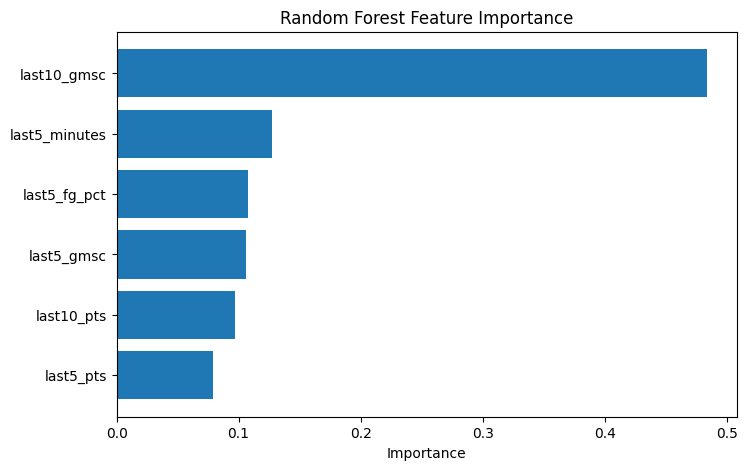

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Interpretation

The Random Forest model identifies which recent performance indicators contribute most strongly to predicting a player's Game Score.

The most important feature is:

- **last10_gmsc (0.48)** — average Game Score across the previous 10 games

This feature alone accounts for nearly 48% of the model's predictive importance, indicating that a player's recent overall impact is the strongest signal for predicting their next-game performance.

The remaining features contribute smaller but meaningful signals:

- **last5_minutes (0.13)** — recent playing time, reflecting player opportunity and role
- **last5_fg_pct (0.11)** — recent shooting efficiency
- **last5_gmsc (0.11)** — short-term overall performance trend
- **last10_pts (0.10)** — longer-term scoring trend
- **last5_pts (0.08)** — very recent scoring performance

Overall, the model relies most heavily on recent Game Score trends, while playing time and shooting efficiency provide additional context about a player's recent form entering a game.

## Model Comparison

To compare the regression models directly, the Linear Regression baseline and
Random Forest Regressor are evaluated side by side using the same metrics.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R²": [lr_r2, rf_r2]
})

comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression,4.678425,6.046475,0.400397
1,Random Forest,4.873921,6.232378,0.362960


### Model Comparison Interpretation

The comparison results show that **Linear Regression slightly outperformed the Random Forest model** on the test dataset.

Performance metrics:

- **Linear Regression**
  - MAE: 4.68
  - RMSE: 6.05
  - R²: 0.40

- **Random Forest**
  - MAE: 4.87
  - RMSE: 6.23
  - R²: 0.36

The Linear Regression model produced lower prediction error (MAE and RMSE) and explained a greater proportion of the variation in Game Score (higher R²).

This result suggests that the relationship between recent player performance statistics and next-game Game Score is largely linear within this feature set. The additional flexibility of the Random Forest model did not provide a performance advantage with the current variables.

Overall, the results indicate that recent rolling performance statistics provide useful predictive signal, but additional contextual features (such as opponent strength, player role, or team pace) may be required to improve predictive accuracy further.

### Classification Model: Predict 20+ Points

In addition to predicting Game Score, the project also models whether a player will score 20 or more points in a game.

This converts the problem into a binary classification task, where the model predicts:

- **0** — player scores fewer than 20 points  
- **1** — player scores 20 or more points  

Threshold-based predictions like this resemble how player prop markets are structured in sports analytics and betting environments.

The model uses the same rolling performance features that were used in the regression models.

In [ ]:
y_20 = model_df["scored_20_plus"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_20,
    test_size=0.2,
    random_state=42
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train_c, y_train_c)

y_pred_c = rf_classifier.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print()
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.8590929106120652

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1890
           1       0.59      0.50      0.55       381

    accuracy                           0.86      2271
   macro avg       0.75      0.72      0.73      2271
weighted avg       0.85      0.86      0.85      2271



### Classification Results: 20+ Points

The classification model predicts whether a player will score 20 or more points in a game using recent rolling performance statistics.

The model achieved an overall accuracy of 0.86, meaning it correctly predicts the outcome in approximately 86% of test cases.

Performance differs across the two classes:

**Class 0 (fewer than 20 points)**  
- Precision: 0.90  
- Recall: 0.93  
- F1-score: 0.92  

**Class 1 (20+ points)**  
- Precision: 0.59  
- Recall: 0.50  
- F1-score: 0.55  

The classifier performs very well at identifying lower-scoring games, but it is less accurate when predicting high-scoring performances. This occurs because 20+ point games are less frequent in the dataset, creating a class imbalance that makes them harder to detect consistently.

Despite this limitation, the classifier provides useful probability estimates that can help identify players with a higher likelihood of exceeding common scoring thresholds.

### Probability Estimates for 20+ Point Predictions

Instead of producing only binary predictions, the classifier can estimate the probability that a player will score 20 or more points in a game.

These probabilities provide a more detailed view of model confidence and can be interpreted similarly to player prop probabilities used in sports analytics and betting markets.

The summary statistics below describe the distribution of predicted probabilities across the test dataset.

In [ ]:
y_prob = rf_classifier.predict_proba(X_test_c)[:, 1]

prob_df = pd.DataFrame({
    "Actual": y_test_c.values,
    "Predicted_Probability_20+": y_prob
})

prob_df.describe()

,Actual,Predicted_Probability_20+
count,2271.000000,2271.000000
mean,0.167768,0.181585
std,0.373742,0.244604
min,0.000000,0.000000
25%,0.000000,0.010000
50%,0.000000,0.065000
75%,0.000000,0.260000
max,1.000000,1.000000


### Probability Distribution of 20+ Point Predictions

To better understand the classifier's behavior, we examine the distribution of predicted probabilities for games where players actually scored 20+ points versus games where they did not.

If the model is effective, games where players scored 20+ points should generally receive higher predicted probabilities.

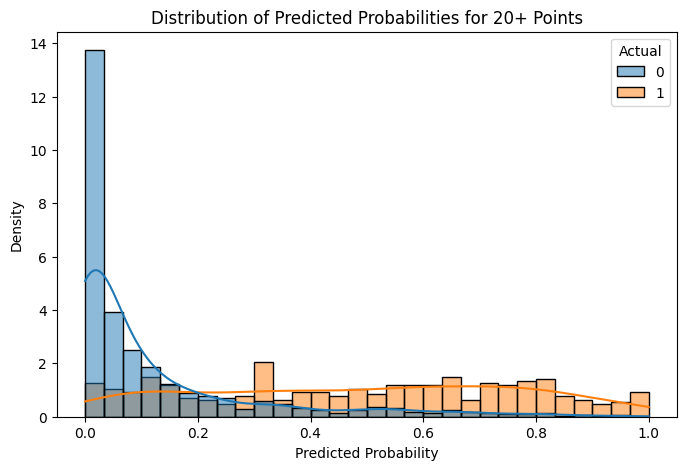

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=prob_df,
    x="Predicted_Probability_20+",
    hue="Actual",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of Predicted Probabilities for 20+ Points")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")

plt.show()

## Probability Distribution Interpretation

This chart shows the distribution of predicted probabilities for whether a player will score 20 or more points in a game. The model assigns each game a probability between 0 and 1 representing how likely it believes the player is to reach the 20-point threshold.

Games where the player did not score 20 points (class 0) are heavily concentrated near very low predicted probabilities. This indicates that the model is generally confident when identifying lower-scoring games and rarely assigns high probabilities to these outcomes.

In contrast, games where the player scored 20 or more points (class 1) are distributed across higher probability values, with many predictions occurring between approximately 0.4 and 0.9. This suggests the model is detecting patterns in the input features that are associated with strong scoring performances.

Some overlap between the two distributions is visible in the middle probability range. These overlapping regions represent games where the model has greater uncertainty. In practical terms, these are likely games where player performance was harder to predict due to factors such as inconsistent recent performance, limited minutes played, or matchup variability.

Overall, the separation between the two distributions indicates that the classifier has learned useful signals from the rolling player statistics. Low probabilities are generally associated with lower scoring outcomes, while higher probabilities correspond more frequently to games where players surpassed the 20-point threshold.

## Classification Model: Predict 25+ Points

A second classification model is trained to predict whether a player will
score 25 or more points.

This is a more selective scoring threshold and is more representative of
high-scoring performances from star players.

In [ ]:
y_25 = model_df["scored_25_plus"]

X_train_25, X_test_25, y_train_25, y_test_25 = train_test_split(
    X,
    y_25,
    test_size=0.2,
    random_state=42
)

rf_classifier_25 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_classifier_25.fit(X_train_25, y_train_25)

y_pred_25 = rf_classifier_25.predict(X_test_25)

print("Accuracy:", accuracy_score(y_test_25, y_pred_25))
print()
print(classification_report(y_test_25, y_pred_25))

Accuracy: 0.9216204315279612

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2084
           1       0.54      0.29      0.38       187

    accuracy                           0.92      2271
   macro avg       0.74      0.64      0.67      2271
weighted avg       0.91      0.92      0.91      2271



### Classification Results: 25+ Points

The 25+ point model evaluates a more demanding scoring threshold than the
20+ point model.

Because 25-point games are less common, this classification problem is more
selective and may be more difficult, but it also aligns closely with
high-end player prop style analysis.

In [ ]:
y_prob_25 = rf_classifier_25.predict_proba(X_test_25)[:, 1]

prob_25_df = pd.DataFrame({
    "Actual_25+": y_test_25.values,
    "Predicted_Probability_25+": y_prob_25
})

prob_25_df.describe()

,Actual_25+,Predicted_Probability_25+
count,2271.000000,2271.000000
mean,0.082343,0.094720
std,0.274946,0.168191
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.010000
75%,0.000000,0.110000
max,1.000000,0.960000


### Predicted Probability Distribution: 25+ Points

The probability distribution for 25+ point games shows how likely the model
believes a player is to produce a high-scoring performance.

Because this threshold is higher than 20 points, predicted probabilities are
expected to be lower overall.

## Vegas-Style Player Performance Predictions

To make the classification results more interpretable in a real-world context,
the predicted probabilities can be viewed similarly to simulated player prop
estimates.

This section uses the 20+ point model to generate a simple threshold-based
“lean” for whether a player appears more likely to go over or under 20 points.

In [ ]:
vegas_df = X_test_c.copy().reset_index()

vegas_df["Player"] = model_df.loc[vegas_df["index"], "Player"].values
vegas_df["Date"] = model_df.loc[vegas_df["index"], "Data"].values
vegas_df["Actual_PTS"] = model_df.loc[vegas_df["index"], "PTS"].values
vegas_df["Actual_20+"] = y_test_c.reset_index(drop=True)
vegas_df["Predicted_Probability_20+"] = y_prob

vegas_df["Model_Lean"] = np.where(
    vegas_df["Predicted_Probability_20+"] >= 0.50,
    "Lean Over 20",
    "Lean Under 20"
)

vegas_df[["Player", "Date", "Actual_PTS", "Actual_20+", "Predicted_Probability_20+", "Model_Lean"]].head(15)

,Player,Date,Actual_PTS,Actual_20+,Predicted_Probability_20+,Model_Lean
0,Julian Phillips,2025-01-25,2,0,0.000,Lean Under 20
1,Lindy Waters III,2025-01-31,0,0,0.005,Lean Under 20
2,Caleb Houstan,2024-11-29,0,0,0.000,Lean Under 20
3,Carlton Carrington,2025-01-16,6,0,0.050,Lean Under 20
4,Jamison Battle,2024-11-29,5,0,0.030,Lean Under 20
5,KJ Simpson,2025-01-29,7,0,0.000,Lean Under 20
6,Spencer Dinwiddie,2025-01-14,8,0,0.130,Lean Under 20
7,Kyrie Irving,2024-11-17,23,1,0.770,Lean Over 20
8,Jonas Valančiūnas,2025-01-08,14,0,0.185,Lean Under 20
9,Mohamed Bamba,2024-12-13,2,0,0.000,Lean Under 20


## Model Evaluation Summary

The regression and classification models demonstrate that recent player performance contains useful signals for predicting scoring outcomes.

The regression model captures general trends in player performance and produces reasonable estimates of Game Score based on recent box score statistics.

The classification model performs well at identifying lower-scoring games, assigning very low probabilities to most games where players fail to reach the 20-point threshold. Higher predicted probabilities are more commonly associated with games where players exceed this scoring level.

Some overlap between prediction groups remains, which is expected in sports data due to game-to-game variability, changes in minutes played, and matchup effects. Despite this uncertainty, the model shows meaningful separation between high-scoring and lower-scoring performances.

## Model Limitations

Several factors limit the predictive power of this model.

The dataset relies only on box score statistics and does not include contextual variables such as defensive matchups, injuries, lineup changes, or team pace. These factors can significantly influence player scoring outcomes.

Additionally, player performance in basketball is inherently volatile. Even players with consistent historical trends can have large deviations in individual games due to random variation.

Finally, the model relies on rolling statistics from recent games, which may not fully capture long-term performance patterns or sudden changes in player roles.

## Potential Improvements

Future versions of this project could improve predictive performance by incorporating additional features.

Team-level metrics such as defensive rating, pace of play, and opponent strength could provide better context for predicting scoring outcomes.

More advanced modeling techniques such as gradient boosting, XGBoost, or neural networks could also improve predictive accuracy compared to the baseline models used here.

Another potential improvement would be the inclusion of player usage rate, shot attempts, and lineup information to better capture how frequently a player is involved in offensive possessions.

## Practical Application

One practical use of this project is in player prop analysis. Since the classification model estimates the probability that a player will score 20 or more points, the same general approach can be adapted to support over/under style decisions for player point lines.

In a real-world setting, a system like this could take a player's recent game history, calculate rolling performance statistics, and generate a probability estimate for whether the player is likely to exceed a selected scoring threshold.

For example, if a user's scoring line for a player is set at 20.5 points, the model could provide a probability-based lean such as:

- lean over
- lean under
- no edge

This type of system would not guarantee outcomes, since basketball performance is affected by injuries, minutes, matchups, and game flow, but it could help structure decision-making using data rather than intuition alone.

Beyond sports picks, the same framework could also be used for general sports analytics applications such as player trend tracking, matchup previews, or performance forecasting dashboards.

## Future Portfolio Extension

A strong extension of this project would be a web application that allows a user to select a player, view recent performance trends, and receive a model-based over/under lean for a scoring line.

The application could combine machine learning predictions with recent rolling averages and simple confidence indicators to present an easy-to-read recommendation interface. This would transform the current notebook from a static data science project into an interactive sports analytics tool.

Such a project would be valuable for a portfolio because it would demonstrate data preparation, machine learning, model deployment, web development, and user-focused design in a single end-to-end application.

## Conclusion

This project demonstrates how machine learning can be applied to sports analytics to estimate player performance outcomes using historical game data.

By using rolling statistics from prior games, the models simulate a realistic prediction environment where only past information is available. The results show that recent performance trends provide meaningful signals for identifying likely high-scoring games.

While the models presented here are relatively simple, they illustrate the core workflow used in many sports analytics pipelines: data preparation, feature engineering, model training, and performance evaluation.

With additional data and more advanced modeling techniques, this approach could be extended to produce more accurate player performance forecasts and support decision-making in sports analytics contexts.